# Libs

In [158]:
import os
from os.path import join as pjoin
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import seaborn as sns
import numpy as np
import pyvista as pv
import math
import jax
import jax.numpy as jnp
from functools import partial

# Import Files

In [2]:
base_dir = pjoin("..", "PumpStaticROM", "data", "raw")
comsol_dir = pjoin(base_dir, "comsol")
output_dir = pjoin(base_dir, "merged_stls")
os.makedirs(output_dir, exist_ok=True)

vtu_path = pjoin(comsol_dir, "Pump2D_MRFStudy_finer_Main.vtu")
outlet_path = pjoin(comsol_dir, "Pump2D_MRFStudy_finer_Outlet.vtu")

In [3]:
if os.path.exists(vtu_path):
    print("Reading 2D pump mesh VTU...")
    grid = pv.read(vtu_path)
else:
    raise FileNotFoundError

Reading 2D pump mesh VTU...


In [4]:
if os.path.exists(outlet_path):
    print("Reading 2D pump mesh VTU...")
    grid_out = pv.read(outlet_path)
else:
    raise FileNotFoundError

Reading 2D pump mesh VTU...


# Boundaries and Lines

In [5]:
print("Extracting boundary contour lines...")
# Extract outer boundary edges (free edges only shared by 1 cell)
boundary = grid.extract_feature_edges(
    boundary_edges=True,
    feature_edges=False,
    manifold_edges=False,
    non_manifold_edges=False
)
print(f"  -> Extracted boundary: {boundary.n_points:,} points, {boundary.n_cells:,} line segments")

Extracting boundary contour lines...
  -> Extracted boundary: 821 points, 829 line segments


In [6]:
connected = boundary.connectivity()
bodies = connected.split_bodies()

In [7]:
# Plot directly in 2D with interactive viewer
plotter = pv.Plotter()
# Configure discrete colorbar arguments
n_regions = int(connected["RegionId"].max()) + 2
scalar_bar_args = dict(
    title="Region ID",
    n_labels=n_regions,  # Match exactly the number of discrete regions
    fmt="%.0f",  # Format labels as clean integers (0, 1, 2...)
    italic=False,
    bold=True,
)

plotter.add_mesh(connected, scalars="RegionId", cmap="tab10", line_width=3, categories=False, render_lines_as_tubes=False, scalar_bar_args=scalar_bar_args)
plotter.view_xy()
plotter.enable_parallel_projection()
plotter.show()

Widget(value='<iframe src="http://localhost:39637/index.html?ui=P_0x7da191540440_0&reconnect=auto" class="pyvi…

In [8]:
# 2. Compute subplot grid dimensions (e.g. 2x3 or 1xN)
n_bodies = len(bodies)
cols = min(3, n_bodies)
rows = math.ceil(n_bodies / cols)

# 3. Create PyVista Plotter with subplots
plotter = pv.Plotter(shape=(rows, cols), window_size=[400 * cols, 400 * rows])

# 4. Iterate over each body and add to its subplot
for i, body in enumerate(bodies):
  row_idx = i // cols
  col_idx = i % cols

  # Activate the specific subplot panel
  plotter.subplot(row_idx, col_idx)

  # Add mesh to current subplot
  plotter.add_mesh(body, color="crimson", line_width=4)

  # Add title with point count
  plotter.add_text(
      f"Body {i} ({body.n_points} pts)", font_size=11, color="black"
  )

  # Configure 2D orthographic camera view
  plotter.view_xy()
  plotter.enable_parallel_projection()
  plotter.show_bounds(grid="back", location="outer", color="gray")

# 5. Display the subplot window
plotter.show()


Widget(value='<iframe src="http://localhost:39637/index.html?ui=P_0x7da16bf5e0d0_1&reconnect=auto" class="pyvi…

## Real Field from Simulation

In [9]:
fields_names = list(grid.point_data.keys())
fields_names[:4]

['Velocity_field,_x_component_@_1:_Q_in=0.1_m^3/h,_rot_rpm=1000_rpm',
 'Velocity_field,_y_component_@_1:_Q_in=0.1_m^3/h,_rot_rpm=1000_rpm',
 'Velocity_field,_z_component_@_1:_Q_in=0.1_m^3/h,_rot_rpm=1000_rpm',
 'Pressure_@_1:_Q_in=0.1_m^3/h,_rot_rpm=1000_rpm']

In [10]:
point_data = grid.point_data
abs_vels = np.linalg.norm(
    np.column_stack([point_data[fields_names[1]],
               point_data[fields_names[0]]
              ]), axis=1
)

In [11]:
plotter = pv.Plotter()
plotter.add_mesh(grid,
                 scalars=abs_vels
                 # scalars=fields_names[1]
)
plotter.view_xy()
plotter.show()

Widget(value='<iframe src="http://localhost:39637/index.html?ui=P_0x7da16bf5fed0_2&reconnect=auto" class="pyvi…

Observe that the MRF is exactly between the body 8 and the inlet. Also, the output of the pump seems "blocked" since the lines were obtained from the boundaries of the volume. That said, Lets remove the outlet boundary line, and also make a SDF calculation for the MRF such that:
$SFD_{MRF}(x,y) = |MRF - (x,y)| \text{ if (x,y) outside the MRF region, else invert the signal}$

In [12]:
grid_out_coords = grid_out.points[:, :2]

## Remove Outlet Line

In [40]:
# 1. Load outlet coordinates and sort them to form sequential line segments       
outlet_path = pjoin(base_dir, "comsol", "Pump2D_MRFStudy_finer_Outlet.vtu")
grid_out = pv.read(outlet_path)                                                   
outlet_raw = grid_out.points[:, :2]                                               

In [ ]:
casing_poly = bodies[0]
casing_poly = (                                     
    casing_body.extract_surface(algorithm="dataset_surface")
    if not isinstance(casing_body, pv.PolyData)     
    else casing_body    
)

In [ ]:
casing_pts = casing_poly.points[:, :2]
outlet_pts = grid_out.points[:, :2]   
                        
# 2. Identify casing points that belong to the outlet
dists = np.linalg.norm(                             
    casing_pts[:, None, :] - outlet_pts[None, :, :], axis=2
).min(axis=1)                                       
is_outlet_pt = dists < 1e-4
     

In [ ]:
                   
# 3. Find the two extreme corner indices of the outlet along the X-axis
outlet_indices = np.where(is_outlet_pt)[0]          
left_corner_idx = outlet_indices[np.argmin(casing_pts[outlet_indices, 0])]
right_corner_idx = outlet_indices[np.argmax(casing_pts[outlet_indices, 0])]
                                                    
# 4. Filter the line segments
# We want to remove a segment only if BOTH endpoints are outlet points,
# EXCEPT if the segment connects one of the extreme corner points to the casing.
lines_mat = casing_poly.lines.reshape(-1, 3)        
p1 = lines_mat[:, 1]    
p2 = lines_mat[:, 2]

In [ ]:
# Segment is an outlet segment to be removed if:
# - Both endpoints are outlet points            
# - AND it does not connect to the outside casing via the corners
is_outlet_seg = is_outlet_pt[p1] & is_outlet_pt[p2] 
                        
# Identify the segments that span across the outlet opening (the ones to delete)
# We exclude the segments that connect the corner points to the casing          
to_remove = []                                      
for i, (idx1, idx2) in enumerate(zip(p1, p2)):
  if is_outlet_seg[i]:  
    # If the segment is inside the outlet opening, remove it
    to_remove.append(i)                             

In [38]:
# Remove the line segments across the opening
open_lines_flat = lines_mat[~np.isin(np.arange(len(lines_mat)), to_remove)].ravel()
                                                    
# 5. Create the open casing PolyData (points are preserved, but the loop is cut open)
open_casing = pv.PolyData(casing_poly.points, lines=open_lines_flat)

In [43]:
plotter = pv.Plotter()
plotter.add_mesh(open_casing, line_width=5, color='black')
plotter.show()

Widget(value='<iframe src="http://localhost:39637/index.html?ui=P_0x7da0fc095950_6&reconnect=auto" class="pyvi…

## Compute Points inside Inlet (Body 10)

In [258]:
inlet_path = pjoin(base_dir, 'comsol', 'Pump2D_MRFStudy_finer_Inlet.vtu')
inlet_mesh = pv.read(inlet_path)

inlet_pts = inlet_mesh.points
b10 = bodies[10]

In [249]:
plotter = pv.Plotter()
plotter.add_mesh(inlet_mesh, line_width=3, color='blue', label="Line from Volume Bodies")
plotter.add_points(b10, line_width=1, color='red', point_size=10, render_points_as_spheres=True, label="Line from Surface")
plotter.add_legend()
plotter.show()

Widget(value='<iframe src="http://localhost:39637/index.html?ui=P_0x7d9ebcc0d450_27&reconnect=auto" class="pyv…

### Is Inside Polygon Function

In [281]:
@jax.jit
@partial(jax.vmap, in_axes=(0, None, None))
def is_inside_polygon_jax(pt, seg_starts, seg_ends):
  """Checks if a batch of 2D points lies inside a closed polygon boundary.

  Vectorized over query_pts batch (axis 0) and JIT-compiled.
  """
  x, y = pt[0], pt[1]
  x1, y1 = seg_starts[:, 0], seg_starts[:, 1]
  x2, y2 = seg_ends[:, 0], seg_ends[:, 1]

  intersect_y = (y1 > y) != (y2 > y)

  dy = y2 - y1
  dy_safe = jnp.where(dy == 0, 1e-12, dy)
  intersect_x = (x < (x2 - x1) * (y - y1) / dy_safe + x1) & (y1 != y2)

  # Even-Odd Rule: Ray-crossing count must be odd to be inside
  intersection_count = jnp.sum(intersect_y & intersect_x)
  is_inside = intersection_count % 2 == 1

  return is_inside


### SDF Function

In [213]:
@jax.jit                                                                    
@partial(jax.vmap, in_axes=(0, None, None))                                 
def compute_unsorted_lines_sdf_jax(pt, seg_starts, seg_ends):               
  A = seg_starts  # (M, 2)                                                  
  B = seg_ends  # (M, 2)                                                    
                                                                            
  AB = B - A                                                                
  AP = pt - A                                                               
                                                                            
  # Distance to segments                                                    
  ab_sq = jnp.sum(AB**2, axis=1)                                            
  ab_sq = jnp.where(ab_sq == 0, 1e-12, ab_sq)                               
                                                                            
  t = jnp.sum(AP * AB, axis=1) / ab_sq                                      
  t = jnp.clip(t, 0.0, 1.0)[:, None]                                        
                                                                            
  closest = A + t * AB                                                      
  abs_distance = jnp.min(jnp.linalg.norm(pt - closest, axis=1))

  # Ray casting for sign
  x, y = pt[0], pt[1]
  x1, y1 = seg_starts[:, 0], seg_starts[:, 1]
  x2, y2 = seg_ends[:, 0], seg_ends[:, 1]

  intersect_y = (y1 > y) != (y2 > y)

  dy = y2 - y1
  dy_safe = jnp.where(dy == 0, 1e-12, dy)
  intersect_x = (x < (x2 - x1) * (y - y1) / dy_safe + x1) & (y1 != y2)

  is_inside = jnp.sum(intersect_y & intersect_x) % 2 == 1

  return jnp.where(is_inside, -abs_distance, abs_distance)


#### Clean Lines with duplicated points

In [265]:
def clean_line(body):
    """Takes any PyVista line/body, merges duplicate points, sorts them, and
    
    returns clean starts, ends, and PolyData mesh.
    """
    poly = (
      body.extract_surface(algorithm="dataset_surface")
      if not isinstance(body, pv.PolyData)
      else body
    )
    
    # 1. Extract unique 2D coordinates
    pts = np.unique(np.round(poly.points[:, :2], 6), axis=0)
    
    # 2. Sort points by polar angle around centroid
    xc = (pts[:, 0].min() + pts[:, 0].max()) / 2.0
    yc = (pts[:, 1].min() + pts[:, 1].max()) / 2.0
    angles = np.arctan2(pts[:, 1] - yc, pts[:, 0] - xc)
    sorted_pts = pts[np.argsort(angles)]
    
    # 3. Define closed 2D segment starts and ends
    starts = sorted_pts
    ends = np.roll(sorted_pts, -1, axis=0)
    
    # 4. Convert 2D -> 3D (Z=0) for PyVista MultipleLines
    pts_3d = np.column_stack([sorted_pts, np.zeros(len(sorted_pts))])
    pts_3d_closed = np.vstack([pts_3d, pts_3d[0]])  # Close the loop
    clean_mesh = pv.MultipleLines(points=pts_3d_closed)
    
    return starts, ends, clean_mesh


In [294]:
starts, ends, cleanb10 = clean_line(b10)

In [243]:
# b10poly = b10.extract_surface().strip().extract_cells([0]).clean()
# starts = b10poly.points[:,:2]
# ends = np.roll(starts, -1, axis=0)
b10poly = b10.extract_surface()
b10lines = b10poly.clean().lines.reshape(-1,3)
p1_idx = b10lines[:,1]
p2_idx = b10lines[:,2]
starts = b10poly.points[p1_idx, :2]
ends = b10poly.points[p2_idx, :2]

/tmp/ipykernel_245023/2469801764.py:4: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  b10poly = b10.extract_surface()


In [283]:
# 1. Define grid bounds based on your boundary coordinates (points_2d)                 
margin = 0.015  # Add a small boundary margin                                          
points_2d = grid.points[:,:2]
x_min, x_max = points_2d[:, 0].min() - margin, points_2d[:, 0].max() + margin          
y_min, y_max = points_2d[:, 1].min() - margin, points_2d[:, 1].max() + margin          
                                                                                       
# 2. Create the 2D grid of query points                                                
grid_res = 1000  # Grid resolution (250 x 250 points)                                   
x_range = jnp.linspace(x_min, x_max, grid_res)
y_range = jnp.linspace(y_min, y_max, grid_res)
X, Y = jnp.meshgrid(x_range, y_range)                                                   
                                                                                       
# Flatten grid into a batch of (N, 2) query points                                     
query_grid = np.column_stack([X.ravel(), Y.ravel()])                                   
                                                                                       
# 3. Convert to JAX and run the SDF function
starts_jax = jnp.array(starts)
ends_jax = jnp.array(ends)
query_grid_jax = jnp.array(query_grid)


In [273]:
# sdf_values = compute_unsorted_lines_sdf_jax(query_grid_jax, starts_jax, ends_jax)

In [284]:
is_inside = is_inside_polygon_jax(query_grid_jax, starts_jax, ends_jax)

#### Plot

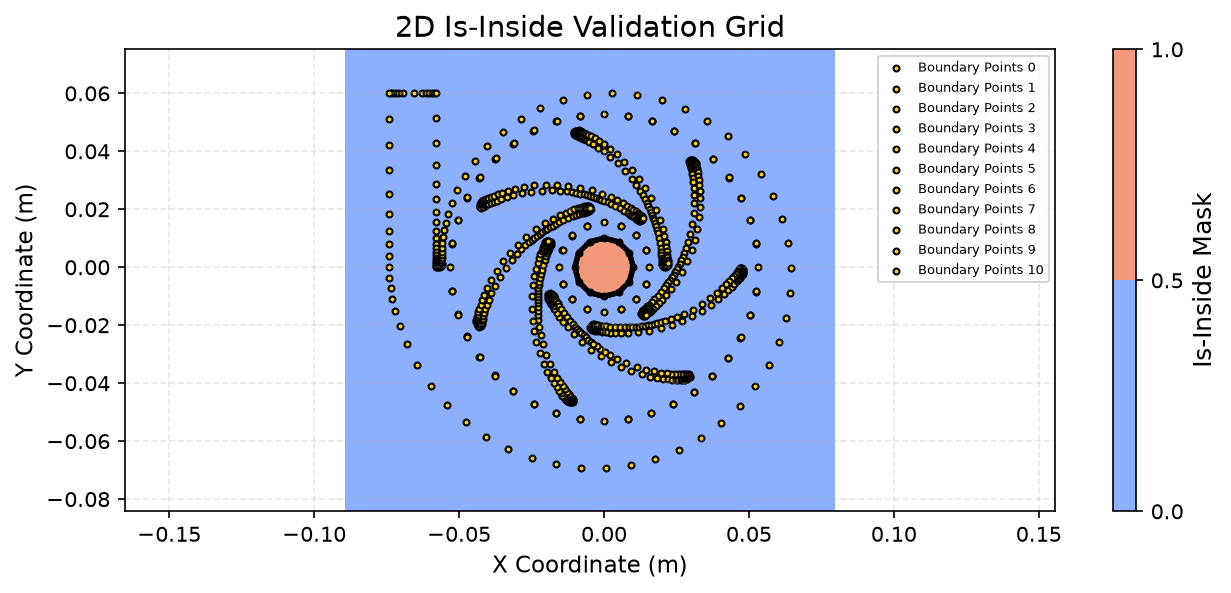

In [319]:
# 4. Plot the SDF field        
# grid_res=400
# SDF_2D = np.array(sdf_values).reshape(grid_res, grid_res)
SDF_2D = np.array(is_inside).reshape(grid_res, grid_res)
plt.figure(figsize=(10, 4), dpi=150)                                                     
                                                                                         
# Fill contours of the SDF field (cool = negative/inside, warm = positive/outside)       
contour = plt.contourf(X, Y, SDF_2D, levels=1, cmap="coolwarm")                         
cbar = plt.colorbar(contour)                                                             
cbar.set_label("Is-Inside Mask", fontsize=12)                                              
                                                                                         
# Draw the 0-level contour line (this highlights the exact reconstructed boundary)       
plt.contour(X, Y, SDF_2D, levels=[0.0], colors="black", linewidths=2.5)                  
                                                                                         
# Plot original boundary points for visual verification                                  
# plt.scatter(                                                                             
#     cleanb10.points[:, 0],                                                                     
#     cleanb10.points[:, 1],                                                                     
#     color="gold",                                                                        
#     s=8,                                                                                 
#     edgecolor="black",                                                                   
#     label="Boundary Points",                                                             
# )                                                                                        
for i, body in enumerate(bodies):
    plt.scatter(                                                                             
        body.points[:, 0],                                                                     
        body.points[:, 1],                                                                     
        color="gold",                                                                        
        s=8,                                                                                 
        edgecolor="black",                                                                   
        label=f"Boundary Points {i}",                                                             
    )     
                                                                                         
plt.title("2D Is-Inside Validation Grid", fontsize=14)              
plt.xlabel("X Coordinate (m)", fontsize=11)                                              
plt.ylabel("Y Coordinate (m)", fontsize=11)                                              
plt.axis("equal")                                                                        
plt.grid(True, linestyle="--", alpha=0.3)                                                
plt.legend(loc="upper right", fontsize=6)                                                            
plt.show()                                                                               


### MRF Signed Distance Function Region - Body 8

In [293]:
b8 = bodies[8]
starts8, ends8, cleanb8 = clean_line(b8)

In [298]:
starts_stack = jnp.vstack([starts8, starts])
ends_stack = jnp.vstack([ends8, ends])


In [289]:
# 1. Define grid bounds based on your boundary coordinates (points_2d)                 
margin = 0.015  # Add a small boundary margin                                          
points_2d = grid.points[:,:2]
x_min, x_max = points_2d[:, 0].min() - margin, points_2d[:, 0].max() + margin          
y_min, y_max = points_2d[:, 1].min() - margin, points_2d[:, 1].max() + margin          
                                                                                       
# 2. Create the 2D grid of query points                                                
grid_res = 1000  # Grid resolution (250 x 250 points)                                   
x_range = jnp.linspace(x_min, x_max, grid_res)
y_range = jnp.linspace(y_min, y_max, grid_res)
X, Y = jnp.meshgrid(x_range, y_range)                                                   
                                                                                       
# Flatten grid into a batch of (N, 2) query points                                     
query_grid = np.column_stack([X.ravel(), Y.ravel()])                                   
                                                                                       
# 3. Convert to JAX and run the SDF function
starts_jax = jnp.array(starts)
ends_jax = jnp.array(ends)
query_grid_jax = jnp.array(query_grid)


In [302]:
sdf_values = compute_unsorted_lines_sdf_jax(query_grid_jax, starts_jax, ends_jax)
sdf_values_stack = compute_unsorted_lines_sdf_jax(query_grid_jax, starts_stack, ends_stack)

#### Plot

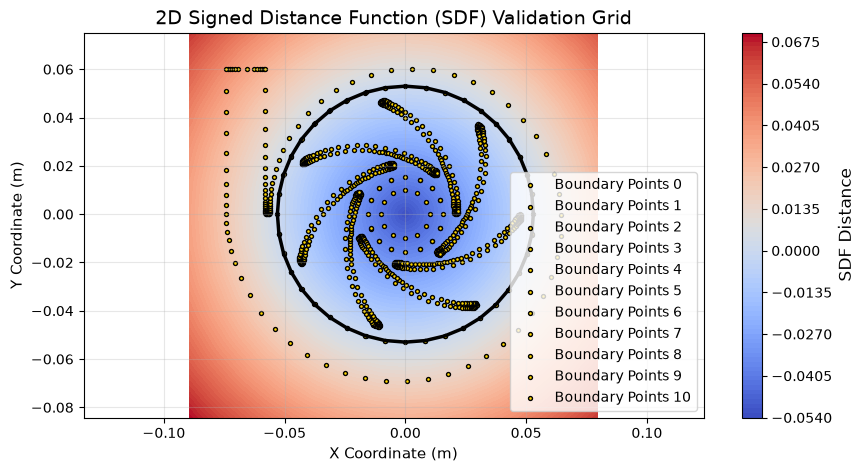

In [320]:
# 4. Plot the SDF field        
# grid_res=400
# SDF_2D = np.array(sdf_values_stack).reshape(grid_res, grid_res)
SDF_2D = np.array(sdf_values).reshape(grid_res, grid_res)
plt.figure(figsize=(10, 5))                                                     
                                                                                         
# Fill contours of the SDF field (cool = negative/inside, warm = positive/outside)       
contour = plt.contourf(X, Y, SDF_2D, levels=100, cmap="coolwarm")                         
cbar = plt.colorbar(contour)                                                             
cbar.set_label("SDF Distance", fontsize=12)                                              
                                                                                         
# Draw the 0-level contour line (this highlights the exact reconstructed boundary)       
plt.contour(X, Y, SDF_2D, levels=[0.0], colors="black", linewidths=2.5)                  
                                                                                         
# Plot original boundary points for visual verification
for i, body in enumerate(bodies):
    plt.scatter(                                                                             
        body.points[:, 0],                                                                     
        body.points[:, 1],                                                                     
        color="gold",                                                                        
        s=8,                                                                                 
        edgecolor="black",                                                                   
        label=f"Boundary Points {i}",                                                             
    )                                                                                        
# plt.scatter(                                                                             
# cleanb10.points[:, 0],                                                                     
# cleanb10.points[:, 1],                                                                     
# color="gold",                                                                        
# s=8,                                                                                 
# edgecolor="black",                                                                   
# label="Boundary Points 10",                                                             
# )                                                                                        
plt.title("2D Signed Distance Function (SDF) Validation Grid", fontsize=14)              
plt.xlabel("X Coordinate (m)", fontsize=11)                                              
plt.ylabel("Y Coordinate (m)", fontsize=11)                                              
plt.axis("equal")                                                                        
plt.grid(True, linestyle="-", alpha=0.3)                                                
plt.legend()                                                            
plt.show()                                                                               


## Blades SDF

In [384]:
blade_bodies_idx = [1,2,3,4,5,6,7]
starts, ends, clean_bodies_blades = [], [], []
for idx in blade_bodies_idx:
    poly = bodies[idx].extract_surface()
    pts = poly.points[:,:2]
    lines = poly.lines.reshape((-1,3))
    p1, p2 = lines[:,1], lines[:,2]
    starts.append(pts[p1])
    ends.append(pts[p2])
    clean_bodies_blades.append(cl)

/tmp/ipykernel_245023/1271556261.py:4: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  poly = bodies[idx].extract_surface()


In [383]:
ends_stack.shape

(595, 3)

In [385]:
starts_stack = jnp.vstack(starts)
ends_stack = jnp.vstack(ends)

In [386]:
# 1. Define grid bounds based on your boundary coordinates (points_2d)                 
margin = 0.015  # Add a small boundary margin                                          
points_2d = grid.points[:,:2]
x_min, x_max = points_2d[:, 0].min() - margin, points_2d[:, 0].max() + margin          
y_min, y_max = points_2d[:, 1].min() - margin, points_2d[:, 1].max() + margin          
                                                                                       
# 2. Create the 2D grid of query points                                                
grid_res = 1000  # Grid resolution (250 x 250 points)                                   
x_range = jnp.linspace(x_min, x_max, grid_res)
y_range = jnp.linspace(y_min, y_max, grid_res)
X, Y = jnp.meshgrid(x_range, y_range)                                                   
                                                                                       
# Flatten grid into a batch of (N, 2) query points                                     
query_grid = np.column_stack([X.ravel(), Y.ravel()])                                   
                                                                                       
# 3. Convert to JAX and run the SDF function
query_grid_jax = jnp.array(query_grid)


In [387]:
# sdf_values = compute_unsorted_lines_sdf_jax(query_grid_jax, starts_jax, ends_jax)
_, sdf_values_stack = jax.lax.scan(
    lambda carry, batch: (carry, compute_unsorted_lines_sdf_jax(batch, starts_stack, ends_stack)),
    None,
    query_grid_jax.reshape(-1,batch_size,2),
    )

In [388]:
sdf_values_stack = sdf_values_stack.flatten()

#### Plot

In [392]:
bodies[3].points.shape

(85, 3)

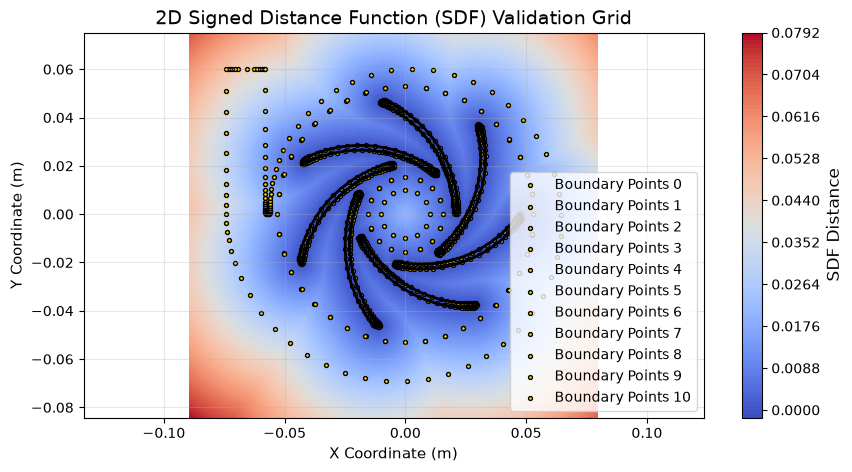

In [390]:
# 4. Plot the SDF field        
# grid_res=400
SDF_2D = np.array(sdf_values_stack).reshape(grid_res, grid_res)
# SDF_2D = np.array(sdf_values).reshape(grid_res, grid_res)
plt.figure(figsize=(10, 5))                                                     
                                                                                         
# Fill contours of the SDF field (cool = negative/inside, warm = positive/outside)       
contour = plt.contourf(X, Y, SDF_2D, levels=100, cmap="coolwarm")                         
cbar = plt.colorbar(contour)                                                             
cbar.set_label("SDF Distance", fontsize=12)                                              
                                                                                         
# Draw the 0-level contour line (this highlights the exact reconstructed boundary)       
plt.contour(X, Y, SDF_2D, levels=[0.0], colors="black", linewidths=2)                  
                                                                                         
# Plot original boundary points for visual verification
for i, body in enumerate(bodies):
    plt.scatter(                                                                             
        body.points[:, 0],                                                                     
        body.points[:, 1],                                                                     
        color="gold",                                                                        
        s=8,                                                                                 
        edgecolor="black",                                                                   
        label=f"Boundary Points {i}",                                                             
    )                                                                                        
# plt.scatter(                                                                             
# cleanb10.points[:, 0],                                                                     
# cleanb10.points[:, 1],                                                                     
# color="gold",                                                                        
# s=8,                                                                                 
# edgecolor="black",                                                                   
# label="Boundary Points 10",                                                             
# )                                                                                        
plt.title("2D Signed Distance Function (SDF) Validation Grid", fontsize=14)              
plt.xlabel("X Coordinate (m)", fontsize=11)                                              
plt.ylabel("Y Coordinate (m)", fontsize=11)                                              
plt.axis("equal")                                                                        
plt.grid(True, linestyle="-", alpha=0.3)                                                
plt.legend()                                                            
plt.show()                                                                               


# SAVE LINES

In [ ]:
# Save as VTP (VTK PolyData - supports lines losslessly)
vtp_output = os.path.join(output_dir, "Pump2D_MRFStudy_finer_contour.vtp")
boundary.save(vtp_output)
print(f"  [Success] Saved contour as VTK PolyData to: {vtp_output}")

# Also save the 2D (x, y) coordinates of the contour points as a NumPy array
pts_2d = boundary.points[:, :2]  # Extract only X and Y coordinates (Z is always 0)
npz_output = os.path.join(output_dir, "Pump2D_MRFStudy_finer_contour.npz")
np.savez(npz_output, points=pts_2d)
print(f"  [Success] Saved 2D contour points as NumPy array to: {npz_output}")
print(f"    -> Shape of saved points: {pts_2d.shape}")
else:
print(f"Error: file not found at {vtu_path}")